<a href="https://colab.research.google.com/github/Addy48/23FE10CSE00457_MLWine/blob/main/KMeans_ML_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install (only needed in Colab)
!pip install seaborn scikit-learn

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [4]:
import pandas as pd

red_wine_df = pd.read_csv("/content/winequality-red.csv", delimiter=';')
white_wine_df = pd.read_csv("/content/winequality-white.csv", delimiter=';')

print("Red wine data loaded. Shape:", red_wine_df.shape)
print("White wine data loaded. Shape:", white_wine_df.shape)

Red wine data loaded. Shape: (1599, 12)
White wine data loaded. Shape: (4898, 12)


In [5]:
# Load datasets
red = pd.read_csv("winequality-red.csv", sep=';')
white = pd.read_csv("winequality-white.csv", sep=';')

# Add type column
red['type'] = 'red'
white['type'] = 'white'

# Combine datasets
df = pd.concat([red, white], ignore_index=True)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [6]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

print("\nMissing Values:\n", df.isnull().sum())

df.describe()

Shape: (6497, 13)

Columns:
 Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type'],
      dtype='object')

Missing Values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [7]:
# Convert type to numeric
df['type'] = df['type'].map({'red': 0, 'white': 1})

In [8]:
# Save quality for later comparison
quality = df['quality']

# Drop target
X = df.drop('quality', axis=1)

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

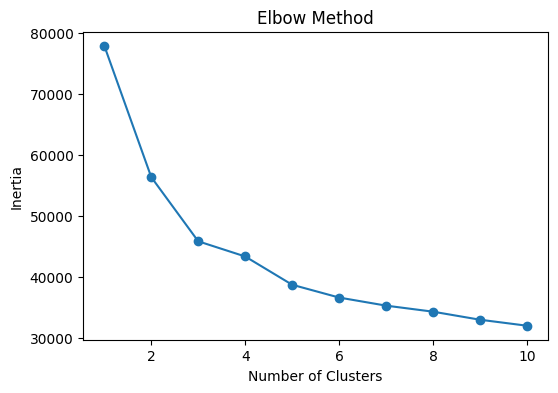

In [11]:
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
# k = 4 (balanced choice)
plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42)

labels = kmeans.fit_predict(X_scaled)

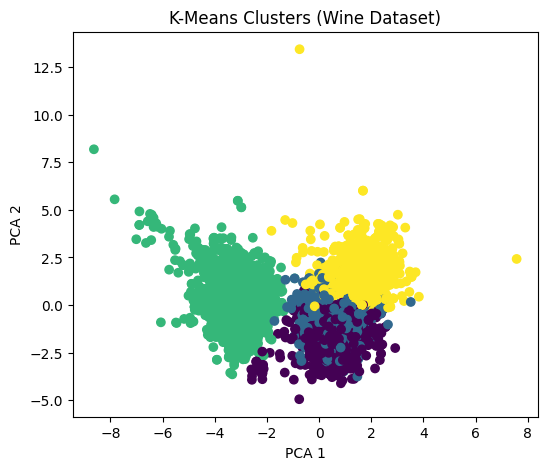

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')
plt.title("K-Means Clusters (Wine Dataset)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [14]:
df['cluster'] = labels

comparison = pd.crosstab(df['cluster'], quality)
print(comparison)

quality   3   4    5    6    7   8  9
cluster                              
0         2  46  263  661  435  92  4
1         6  77  418  760  314  58  0
2        10  54  679  622  189  16  0
3        12  39  778  793  141  27  1


In [15]:
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.18462756238953076


In [16]:
cluster_profile = df.groupby('cluster').mean()
print(cluster_profile)

         fixed acidity  volatile acidity  citric acid  residual sugar  \
cluster                                                                 
0             6.255057          0.278922     0.287804        3.240519   
1             7.262890          0.273148     0.351096        3.714636   
2             8.370127          0.531395     0.271732        2.515892   
3             6.965438          0.283222     0.356019       11.433975   

         chlorides  free sulfur dioxide  total sulfur dioxide   density  \
cluster                                                                   
0         0.039863            32.407518            124.322688  0.992103   
1         0.043321            26.036742            114.728720  0.992387   
2         0.088296            15.674204             45.519745  0.996833   
3         0.052915            46.056951            171.031547  0.997106   

               pH  sulphates    alcohol   quality      type  
cluster                                         

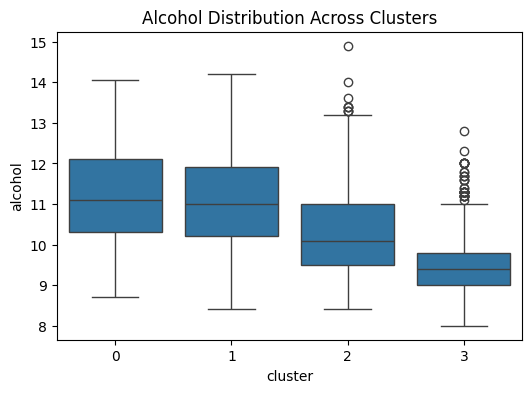

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x='cluster', y='alcohol', data=df)
plt.title("Alcohol Distribution Across Clusters")
plt.show()

In [18]:
df.to_csv("wine_clustered.csv", index=False)
